# Decision Trees

## What Is a Decision Tree?

A Decision Tree is a **non-linear supervised learning algorithm** that learns a hierarchy of if-else rules from data. It splits the training data into increasingly pure subsets by asking questions about features, one at a time, until each subset contains mostly one class.

The structure mirrors human reasoning. A simple example for loan approval:
```
Is income > 50k?
├── Yes → Is age > 30?
│         ├── Yes → Approve Loan
│         └── No  → Reject Loan
└── No  → Reject Loan
```

The algorithm builds these rules **automatically** from data — you do not write them by hand.

## Why Use Decision Trees?

Most algorithms we have studied so far (Logistic Regression, Naive Bayes) assume something about the shape of the data — linearity, Gaussian distributions, feature independence. Decision Trees assume **nothing**. They partition the feature space into rectangles and assign a class to each region.

Key advantages:

- **Interpretable** — the learned rules can be read and explained to non-technical stakeholders
- **Handles non-linear patterns** — no assumption of linearity
- **Works with numeric and categorical features** — no need to encode everything as continuous
- **No feature scaling required** — splits are based on thresholds, not distances or dot products

## The Core Theory: Entropy and Information Gain

The central question a Decision Tree must answer at every node is: **which feature should I split on, and at what threshold?** The answer is found by measuring how much each possible split reduces *impurity* in the resulting subsets.

### Entropy

Entropy $H(S)$ measures the **impurity** of a dataset $S$ — how mixed the class labels are:

$$H(S) = -\sum_{i=1}^{c} p_i \log_2(p_i)$$

Where:

- $c$ is the number of classes
- $p_i$ is the proportion of samples belonging to class $i$

The intuition is straightforward:

- If all samples belong to **one class** → no uncertainty → $H = 0$
- If samples are split **perfectly evenly** → maximum uncertainty → $H = 1$ (binary case)

**Example:** Suppose we have 10 samples, 5 positive and 5 negative:

$$p_1 = 0.5, \quad p_2 = 0.5$$

$$H = -\left[0.5\log_2(0.5) + 0.5\log_2(0.5)\right] = -\left[0.5 \times (-1) + 0.5 \times (-1)\right] = 1$$

Maximum entropy — we have no useful information yet.

### Information Gain

Information Gain ($IG$) measures **how much a split reduces entropy**. For a split that divides parent dataset $S$ into child subsets $S_k$:

$$IG = H(S) - \sum_{k} \frac{|S_k|}{|S|} H(S_k)$$

Where:

- $H(S)$ is the entropy of the parent node
- $|S_k|$ is the number of samples in child subset $k$
- $|S|$ is the total number of samples in the parent
- The weighted sum accounts for the fact that larger children matter more

The algorithm evaluates every possible feature and every possible threshold, then selects the split that maximizes $IG$:

$$\text{Best Split} = \underset{}{\arg\max} \ IG$$

## Gini Impurity: An Alternative to Entropy

Many implementations, including sklearn by default, use **Gini Impurity** instead of entropy:

$$Gini = 1 - \sum_{i=1}^{c} p_i^2$$

Like entropy, Gini is 0 when a node is perfectly pure (one class only) and reaches its maximum when classes are equally distributed. 

The practical difference is small — both metrics tend to produce similar trees. Gini is slightly faster to compute because it avoids the $\log$ operation, which is why sklearn prefers it. Entropy can sometimes produce slightly more balanced trees.

## How the Tree Is Built

The tree is constructed recursively using a greedy algorithm called **CART** (Classification and Regression Trees):

1. Compute the impurity (entropy or Gini) of the current node
2. Try every feature and every possible split threshold
3. Compute the Information Gain for each candidate split
4. Select the split with the highest $IG$
5. Divide the data into two child nodes
6. Repeat recursively on each child

The recursion stops — and a **leaf node** is created — when any of the following conditions are met:

- The node is **pure** (all samples belong to one class)
- **Maximum depth** has been reached (a hyperparameter you control)
- The node has **too few samples** to split further (another hyperparameter)

The leaf node's prediction is simply the **majority class** among its samples.

## Overfitting: The Core Problem

A Decision Tree grown without any stopping conditions will keep splitting until every leaf is pure — perfectly memorizing the training data. On training data, accuracy reaches 100%. On unseen test data, performance collapses.

This happens because the tree learns **noise** in the training data as if it were signal. A single unusual data point can create an entire branch just to classify it correctly.

Two main remedies:

**Pre-pruning** — stop early by setting constraints before the tree is fully grown:

- `max_depth`: limits how deep the tree can go
- `min_samples_split`: minimum samples required to split a node
- `min_samples_leaf`: minimum samples required in a leaf

**Post-pruning** — grow the full tree first, then remove branches that provide little predictive power on a validation set.

The high variance of Decision Trees — small changes in data produce very different trees — is the primary motivation for **Random Forests**, which average many trees to stabilize predictions.

## Advantages and Disadvantages

| | Detail |
|---|---|
| ✅ Interpretable | Rules can be visualized and explained in plain language |
| ✅ Non-linear | Captures complex decision boundaries without feature engineering |
| ✅ No scaling needed | Threshold-based splits are invariant to feature scale |
| ✅ Mixed data types | Handles numeric and categorical features naturally |
| ❌ Overfits easily | Grows arbitrarily complex without pruning |
| ❌ High variance | Sensitive to small changes in training data |
| ❌ Greedy | Locally optimal splits may not lead to globally optimal trees |

The variance problem in particular sets the stage for ensemble methods — Random Forests and Gradient Boosting — which address it by combining many trees rather than relying on a single one.

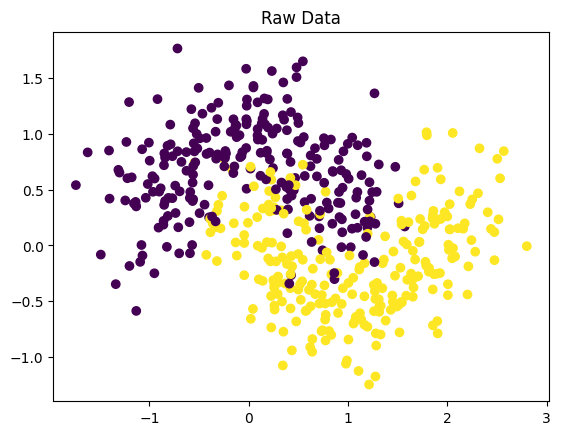

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import make_moons

# Non-linear dataset
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)
# Visualize raw data
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Raw Data")
plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

tree = DecisionTreeClassifier(
    criterion="entropy",  # use entropy instead of gini
    max_depth=4,           # control overfitting
    random_state=42
)

tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [13]:
y_pred = tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.89

Confusion Matrix:
 [[38  5]
 [ 6 51]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87        43
           1       0.91      0.89      0.90        57

    accuracy                           0.89       100
   macro avg       0.89      0.89      0.89       100
weighted avg       0.89      0.89      0.89       100



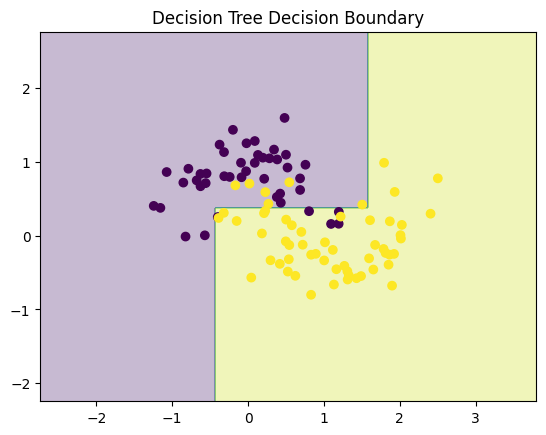

In [14]:
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = tree.predict(grid)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test)
plt.title("Decision Tree Decision Boundary")
plt.show()

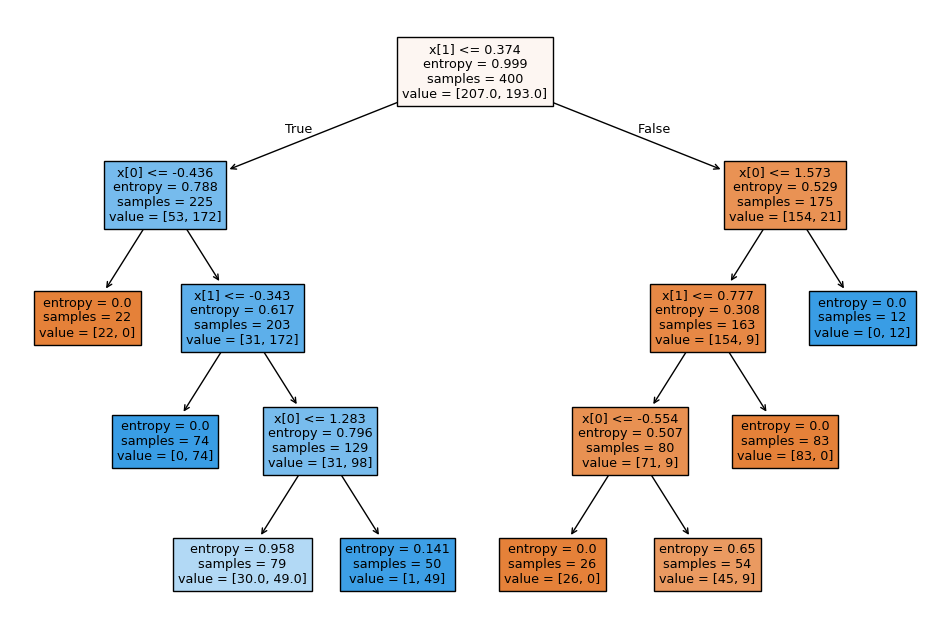

In [15]:
plt.figure(figsize=(12,8))
plot_tree(tree, filled=True)
plt.show()